# Homework: Vaccine Distribution Network

###  Bus 36109 "Advanced Decision Modeling with Python", Don Eisenstein
Don Eisenstein &copy; Copyright 2021, University of Chicago 

A vaccine is being produced at different manufacturing Plants to be distributed across the United States to various Hospitals. Each Plant first ships its vaccines to one or more Warehouses.  The Warehouses then ship the vaccines to the Hospitals.

Our task is to determine the quantities each Plant should ship to each Warehouse, and then the quantities each Warehouse should ship to each Hospital each week.  

There are 6 manufacturing plants, each with a limited weekly capacity (in cases) of vaccine doses. The location of each facility is represented as `(x, y)` map coordinates. 

| Facility | Location   | Capacity |
| ---      |   ----     |  --- |
| Plant 1  | (123, 210) | 200    |
| Plant 2  | (40, 71)   | 50    |
| Plant 3  | (21, 185)  | 150    |
| Plant 4  | (129, 57)  | 40    |
| Plant 5  | (300, 12)  | 100    |
| Plant 6  | (281, 190) | 100    |

There are 3 warehouses. A plant must transport its vaccines to a warehouse first. Vaccines then travel from warehouses to hospitals. 

Each Warehouse has a Capacity to move vaccine through its warehouse each week.  Capacity is in units of vaccine cases per week.  Each warehouse charges a processing cost per case of vaccine that flows through its facility.  Each warehouse must ship out weekly the same quantity of vaccines it receives, that is, we do not store or hold vaccine in a warehouse from one week to the next.

| Facility | Location   | Capacity | Unit Cost per Case |
| ---      |   ----     |  ---     | -- |
| Warehouse 1  | (52, 78) | 500    | 20 |
| Warehouse 2  | (200, 17)   | 250    | 25 |
| Warehouse 3  | (124, 49)  | 750    | 30 |


There are ten regional hospital networks in urgent need of vaccines. Their weekly quantities needed (in cases) and `(x, y)` map coordinates are shown below.

| Facility | Location   | Demand |
| ---      |   ----     |  ---   |
| Hospital 1  | (41, 21) | 50    |
| Hospital 2  | (129, 44)   | 75    |
| Hospital 3  | (61, 210)  | 121    |
| Hospital 4  | (78, 47)  | 231    |
| Hospital 5  | (12, 90)  | 147    |
| Hospital 6  | (70, 250) | 190    |
| Hospital 7  | (63, 194)   | 100    |
| Hospital 8  | (199, 28)  | 151    |
| Hospital 9  | (351, 7)  | 49    |
| Hospital 10  | (222, 163)  | 172    |


Assumption:  You can assume, as this data indicates, that the total Plant capacity is no greater than the Hospital demand.

We estimate our cost of transportation by considering the *Rectilinear* distance between each Plant and Warehouse, and between each Warehouse and Hospital.  Rectilinear travel restricts movement along the horizontal (x) and vertical (y) axes. It is commonly used to approximate travel along a road grid. 

The transportation cost is $1 per vaccine case traveling one unit of our map distance. The rectilinear distance between two points `(x_1, y_1)` and `(x_2, y_2)` is `abs(x_2 - x_1) + abs(y_2 - y_1)`.   The Python `abs` function returns the absolute value of a number.

For example, the distance between `(0, 0)` and `(1, 1)` is `abs(1 - 0) + abs(1 - 0) = 2`, and transporting `100` vaccine cases would therefore cost `100 cases * 2 distance units * $1/(case-distance) = $200`. 

Each manufacturing plant and warehouse seeks to send as many cases as possible in order to meet hospital demand. Because vaccines are extremely valuable, hospitals should not receive any additional cases exceeding their immediate requirements.  Each manufacturing plant can ship vaccines to multiple warehouses, and each warehouse can send vaccine to multiple hospitals. And each hospital can receive vaccines from multiple warehouses. The number of vaccine cases sent and received should be modeled as a Continuous variable ... that is, one can ship a fraction of a case (This is to keep our model quick to solve, not to capture any realities of a transportation network).

Our model will answer the following question:

**What is the optimal allocation of vaccine cases that best meets hospital needs while minimizing total transportation and warehousing costs? In other words, how many cases of vaccines should each manufacturing plant send to each warehouse, and each warehouse to each hospital?** 

**NOTE:  Make all your flow variables Continuous.  That is, it is fine to ship a fraction of a case of vaccine.**

Follow the notebook to walk you through the solution in parts.  Insert your answer to each part into the notebook below the question for each part.

# Your Solution

Insert your answer to each part into this notebook

In [1]:
# === SETUP ===
import pulp
import os
from pprint import pprint

# Portable solver setup, to allow work locally (ARM64 architecture) as well as in JupyterHub
from pulp import COIN_CMD
if os.path.exists('/opt/homebrew/opt/cbc/bin/cbc'):
    solver = COIN_CMD(path='/opt/homebrew/opt/cbc/bin/cbc', msg=0)
else:
    solver = pulp.PULP_CBC_CMD(msg=0)

**1. In broad terms, what are the variables, objective and constraints of this problem? You don't need to list the entire formulation. Just describe the structure/characteristics of your model.**

#### Variables:
  1. $\text{case}_{ij}$, number of vacine cases sent from Plant $i$ to Warehouses $j$ (18 $ij$ pairs).
  2. $\text{case}_{jk}$, number of vacine cases sent from Warehouses $j$ to Hospital $k$ (30 $ij$ pairs).

#### Objective: minimize the total cost of transportation and warehousing
latex$$
C_1 = \sum_{i=1}^{6} \sum_{j=1}^{3} (\text{distance}_{ij} \times \text{case}_{ij})
$$

$$
C_2 = \sum_{j=1}^{3} \sum_{k=1}^{10} (\text{distance}_{jk} \times \text{case}_{jk})
$$

$$
C_3 = \sum_{j=1}^{3} \left( \text{whouse cost}_{j} \times \sum_{k=1}^{10}\text{case}_{jk} \right)
$$

$$
\min \left( C_1 + C_2 + C_3 \right)
$$

#### Constraint set 1: for each plant $(i = 1, ..., 6)$, the sum of all cases traveling to warehouses $(j = 1, ..., 3)$ from it must equal its capacity.
$$\sum_{j=1}^{3}(\text{case}_{ij}) = \text{capacity}_{i} \quad i = 1,...,6$$

#### Constraint set 2: for each warehouse $(j = 1, ..., 3)$, the sum of all cases traveling from plants $(i = 1, ..., 6)$ must not exceed its capacity.
$$\sum_{i=1}^{6}(\text{case}_{ij}) \le \text{capacity}_{j} \quad j = 1,...,3$$

#### Constraint set 3: for each warehouse $(j = 1, ..., 3)$, the sum of all cases traveling to it from plants $(i = 1, ..., 6)$ from it must equal the sum of all cases traveling to all hospitals $(k = 1, ..., 10)$
$$\sum_{i=1}^{6}(\text{case}_{ij}) = \sum_{k=1}^{10}(\text{case}_{jk}) \quad j = 1,...,3$$

#### Constraint set 4: for each hospital $(k = 1, ..., 10)$, the sum of all cases traveling from warehouses $(i = 1, ..., 3)$ must not exceed its demand.
$$\sum_{j=1}^{3}(\text{case}_{jk}) \le \text{demand}_{k} \quad k = 1,...,10$$

#### Constraint set 5: each $\text{case}_{ij}$ is non-negative integers.

**2.  Create a Python List called `plants` to store the information about the plants.   
Each element of the List should be a Dictionary that will have Keys `name`, `capacity`, `x` and `y`.**

**Create a List called `hospitals`.  Each element of the List will be a Dictionary with keys `name`, `demand`, `x` and `y`.**

**Finally create a List called `warehouses`.  Each element of the List will be a Dictionary with keys `name`, `capacity`, `processing_cost', `x` and `y`.**


In [2]:
plants = [
    {'name': 'P1', 'capacity': 200, 'x': 123, 'y': 210}, 
    {'name': 'P2', 'capacity': 50, 'x': 40, 'y': 71},
    {'name': 'P3', 'capacity': 150, 'x': 21, 'y': 185},
    {'name': 'P4', 'capacity': 40, 'x': 129, 'y': 57},
    {'name': 'P5', 'capacity': 100, 'x': 300, 'y': 12},
    {'name': 'P6', 'capacity': 100, 'x': 281, 'y': 190}
]

hospitals = [ 
    {'name': 'H1', 'demand': 50, 'x': 41, 'y': 21},
    {'name': 'H2', 'demand': 75, 'x': 129, 'y': 44},
    {'name': 'H3', 'demand': 121, 'x': 61, 'y': 210},
    {'name': 'H4', 'demand': 231, 'x': 78, 'y': 47},
    {'name': 'H5', 'demand': 147, 'x': 12, 'y': 90},
    {'name': 'H6', 'demand': 190, 'x': 70, 'y': 250},
    {'name': 'H7', 'demand': 100, 'x': 63, 'y': 194},
    {'name': 'H8', 'demand': 151, 'x': 199, 'y': 28},
    {'name': 'H9', 'demand': 49, 'x': 351, 'y': 7},
    {'name': 'H10', 'demand': 172, 'x': 222, 'y': 163}
]

warehouses = [
    {'name': 'W1', 'capacity': 500, 'processing_cost': 20, 'x': 52, 'y': 78},
    {'name': 'W2', 'capacity': 250, 'processing_cost': 25, 'x': 200, 'y': 17},
    {'name': 'W3', 'capacity': 750, 'processing_cost': 30, 'x': 124, 'y': 49},
]

**3. Create a PuLP LpProblem object and store it in the variable `model`.** 

In [3]:
model = pulp.LpProblem('Vaccine_Network', pulp.LpMinimize)

**4. Create a Dictionary `lp_variables` and store in it each PuLP variable.  Each key in the Dictionary should be a Tuple. NOTE: You should have a flow variables only for each Plant-Warehouse combination and for each Warehouse-Hospital combination.  You should NOT have any single variables that contain flow all the way from a Plant through a Warehouse to a Hospital.** 

In [4]:
# Start with an empty dictionary of cases shipped
shipments = {}

# Iterate over plant-warehouse pairs (i-j) and create LpVariables for each
# Key: tuple(plant_name, hospital_name)
# Value: LpVariable representing the number of cases shipped on that route
for plant in plants:
    for warehouse in warehouses:
        # Define pair
        pair = (plant['name'],warehouse['name'])
        # Create PuLP variable for the pair and put in the dictionary
        var_name = f"Cases_{plant['name']}_{warehouse['name']}"
        shipments[pair] = pulp.LpVariable(var_name, lowBound = 0, cat='Continuous')

# Iterate over warehouse-hospital pairs (j-k)
for warehouse in warehouses:
    for hospital in hospitals:
        # Define pair
        pair = (warehouse['name'],hospital['name'])
        # Create PuLP variable for the pair and put in the dictionary
        var_name = f"Cases_{warehouse['name']}_{hospital['name']}"
        shipments[pair] = pulp.LpVariable(var_name, lowBound = 0, cat='Continuous')

**5. Add your objective function to your `model`**

In [5]:
cost = 0.0

# Plant-warehouse transportation cost
for plant in plants:
    for warehouse in warehouses:
        pair = (plant['name'], warehouse['name'])
        distance = abs(plant['x'] - warehouse['x']) + abs(plant['y'] - warehouse['y'])
        cost += distance * shipments[pair]

# Warehouse-hospital transportation cost
for warehouse in warehouses:
    for hospital in hospitals:
        pair = (warehouse['name'], hospital['name'])
        distance = abs(warehouse['x'] - hospital['x']) + abs(warehouse['y'] - hospital['y'])
        cost += distance * shipments[pair]

# Warehouse processing cost
for warehouse in warehouses:
    throughput = 0
    for hospital in hospitals:
        pair = (warehouse['name'], hospital['name'])
        throughput += shipments[pair]
    cost += throughput * warehouse['processing_cost']

model += cost

**6. Add the constraints to your `model`**

In [6]:
# Constraint set 1: Each plant ships exactly its capacity
for plant in plants:
    total_shipped = 0
    for warehouse in warehouses:
        total_shipped += shipments[(plant['name'], warehouse['name'])]
    model += total_shipped == plant['capacity'], f"Plant_Capacity_{plant['name']}"

# Constraint set 2: Each warehouse receives no more than its capacity
for warehouse in warehouses:
    total_received = 0
    for plant in plants:
        total_received += shipments[(plant['name'], warehouse['name'])]
    model += total_received <= warehouse['capacity'], f"Warehouse_Capacity_{warehouse['name']}"

# Constraint set 3: Flow conservation at each warehouse (in = out)
for warehouse in warehouses:
    inflow = 0
    for plant in plants:
        inflow += shipments[(plant['name'], warehouse['name'])]
    outflow = 0
    for hospital in hospitals:
        outflow += shipments[(warehouse['name'], hospital['name'])]
    model += inflow == outflow, f"Flow_Conservation_{warehouse['name']}"

# Constraint set 4: Each hospital receives no more than its demand
for hospital in hospitals:
    total_received = 0
    for warehouse in warehouses:
        total_received += shipments[(warehouse['name'], hospital['name'])]
    model += total_received <= hospital['demand'], f"Hospital_Demand_{hospital['name']}"

# Constraint set 5: Non-negative integers handled by LpVariable definition (lowBound=0, cat='Continuous') # or Integer

**7. Display your model with `print(model)`, check that all is OK**

In [7]:
print(model)

Vaccine_Network:
MINIMIZE
203*Cases_P1_W1 + 270*Cases_P1_W2 + 162*Cases_P1_W3 + 19*Cases_P2_W1 + 214*Cases_P2_W2 + 106*Cases_P2_W3 + 138*Cases_P3_W1 + 347*Cases_P3_W2 + 239*Cases_P3_W3 + 98*Cases_P4_W1 + 111*Cases_P4_W2 + 13*Cases_P4_W3 + 314*Cases_P5_W1 + 105*Cases_P5_W2 + 213*Cases_P5_W3 + 341*Cases_P6_W1 + 254*Cases_P6_W2 + 298*Cases_P6_W3 + 88*Cases_W1_H1 + 275*Cases_W1_H10 + 131*Cases_W1_H2 + 161*Cases_W1_H3 + 77*Cases_W1_H4 + 72*Cases_W1_H5 + 210*Cases_W1_H6 + 147*Cases_W1_H7 + 217*Cases_W1_H8 + 390*Cases_W1_H9 + 188*Cases_W2_H1 + 193*Cases_W2_H10 + 123*Cases_W2_H2 + 357*Cases_W2_H3 + 177*Cases_W2_H4 + 286*Cases_W2_H5 + 388*Cases_W2_H6 + 339*Cases_W2_H7 + 37*Cases_W2_H8 + 186*Cases_W2_H9 + 141*Cases_W3_H1 + 242*Cases_W3_H10 + 40*Cases_W3_H2 + 254*Cases_W3_H3 + 78*Cases_W3_H4 + 183*Cases_W3_H5 + 285*Cases_W3_H6 + 236*Cases_W3_H7 + 126*Cases_W3_H8 + 299*Cases_W3_H9 + 0.0
SUBJECT TO
Plant_Capacity_P1: Cases_P1_W1 + Cases_P1_W2 + Cases_P1_W3 = 200

Plant_Capacity_P2: Cases_P2_W1 + Ca

**8. Solve your optimization model and print its status and the optimal objective function value (the total transportation cost).  NOTE: Your optimal objective function value should be 132966.0**

In [8]:
model.solve(solver)
print(f"Status: {pulp.LpStatus[model.status]}")
print(f"Total cost = ${pulp.value(model.objective)}")

Status: Optimal
Total cost = $132966.0


**9. Output the value of each of your variables at optimality.**

In [9]:
for v in model.variables():
    print(f"{v.name} = {v.varValue}")

Cases_P1_W1 = 0.0
Cases_P1_W2 = 0.0
Cases_P1_W3 = 200.0
Cases_P2_W1 = 50.0
Cases_P2_W2 = 0.0
Cases_P2_W3 = 0.0
Cases_P3_W1 = 150.0
Cases_P3_W2 = 0.0
Cases_P3_W3 = 0.0
Cases_P4_W1 = 0.0
Cases_P4_W2 = 0.0
Cases_P4_W3 = 40.0
Cases_P5_W1 = 0.0
Cases_P5_W2 = 100.0
Cases_P5_W3 = 0.0
Cases_P6_W1 = 0.0
Cases_P6_W2 = 51.0
Cases_P6_W3 = 49.0
Cases_W1_H1 = 36.0
Cases_W1_H10 = 0.0
Cases_W1_H2 = 0.0
Cases_W1_H3 = 0.0
Cases_W1_H4 = 17.0
Cases_W1_H5 = 147.0
Cases_W1_H6 = 0.0
Cases_W1_H7 = 0.0
Cases_W1_H8 = 0.0
Cases_W1_H9 = 0.0
Cases_W2_H1 = 0.0
Cases_W2_H10 = 0.0
Cases_W2_H2 = 0.0
Cases_W2_H3 = 0.0
Cases_W2_H4 = 0.0
Cases_W2_H5 = 0.0
Cases_W2_H6 = 0.0
Cases_W2_H7 = 0.0
Cases_W2_H8 = 151.0
Cases_W2_H9 = 0.0
Cases_W3_H1 = 0.0
Cases_W3_H10 = 0.0
Cases_W3_H2 = 75.0
Cases_W3_H3 = 0.0
Cases_W3_H4 = 214.0
Cases_W3_H5 = 0.0
Cases_W3_H6 = 0.0
Cases_W3_H7 = 0.0
Cases_W3_H8 = 0.0
Cases_W3_H9 = 0.0


**10. Use Python to list each Hospital's Demand, suppy of vaccine, shortfall (amount shy of demand), and percent of demand filled.**

In [10]:
for hospital in hospitals:
    supply = 0
    for warehouse in warehouses:
        supply += shipments[(warehouse['name'], hospital['name'])].varValue
    demand = hospital['demand']
    shortfall = demand - supply
    percent_filled = (supply / demand) * 100
    print(f"{hospital['name']}: Demand={demand}, Supply={supply:.0f}, Shortfall={shortfall:.0f}, Filled={percent_filled:.1f}%")

H1: Demand=50, Supply=36, Shortfall=14, Filled=72.0%
H2: Demand=75, Supply=75, Shortfall=0, Filled=100.0%
H3: Demand=121, Supply=0, Shortfall=121, Filled=0.0%
H4: Demand=231, Supply=231, Shortfall=0, Filled=100.0%
H5: Demand=147, Supply=147, Shortfall=0, Filled=100.0%
H6: Demand=190, Supply=0, Shortfall=190, Filled=0.0%
H7: Demand=100, Supply=0, Shortfall=100, Filled=0.0%
H8: Demand=151, Supply=151, Shortfall=0, Filled=100.0%
H9: Demand=49, Supply=0, Shortfall=49, Filled=0.0%
H10: Demand=172, Supply=0, Shortfall=172, Filled=0.0%


**11. We now want to understand the impact of our transportation costs as we constrain the 
percent of demand satisfied for all hospitals.  Reformulate your model to ensure that the percent of demand satisfied 
to each hospital is at least 20%.  Resolve your model and output the objective function value and hospital supply/demand stats as you did in Part 10.**

In [11]:
# Constraint set 6: 
# Minimum demand fulfillment constraint (P) of 20% for all hospitals
P = 0.20

for hospital in hospitals:
    total_received = 0
    for warehouse in warehouses:
        total_received += shipments[(warehouse['name'], hospital['name'])]
    model += total_received >= P * hospital['demand'], f"{hospital['name']}_min_demand"

In [12]:
for hospital in hospitals:
    supply = 0
    for warehouse in warehouses:
        supply += shipments[(warehouse['name'], hospital['name'])].varValue
    demand = hospital['demand']
    shortfall = demand - supply
    percent_filled = (supply / demand) * 100
    print(f"{hospital['name']}: Demand={demand}, Supply={supply:.0f}, Shortfall={shortfall:.0f}, Filled={percent_filled:.1f}%")

H1: Demand=50, Supply=36, Shortfall=14, Filled=72.0%
H2: Demand=75, Supply=75, Shortfall=0, Filled=100.0%
H3: Demand=121, Supply=0, Shortfall=121, Filled=0.0%
H4: Demand=231, Supply=231, Shortfall=0, Filled=100.0%
H5: Demand=147, Supply=147, Shortfall=0, Filled=100.0%
H6: Demand=190, Supply=0, Shortfall=190, Filled=0.0%
H7: Demand=100, Supply=0, Shortfall=100, Filled=0.0%
H8: Demand=151, Supply=151, Shortfall=0, Filled=100.0%
H9: Demand=49, Supply=0, Shortfall=49, Filled=0.0%
H10: Demand=172, Supply=0, Shortfall=172, Filled=0.0%


**12. Now form a plot.  Vary P along the x-axis from 0 to 1 in steps of 0.05.
Plot the Optimal objective function value for each P along the y-axis.**

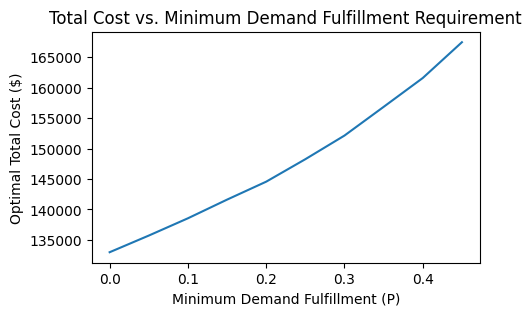

In [13]:
import matplotlib.pyplot as plt

P_values = []
costs = []

for P in [i * 0.05 for i in range(21)]:
    # Create fresh model
    model = pulp.LpProblem("Vaccine_Network", pulp.LpMinimize)
    
    # Recreate shipment variables
    shipments = {}
    for plant in plants:
        for warehouse in warehouses:
            pair = (plant['name'], warehouse['name'])
            var_name = f"Cases_Plant_{plant['name'].split()[-1]}_Warehouse_{warehouse['name'].split()[-1]}"
            shipments[pair] = pulp.LpVariable(var_name, lowBound=0, cat='Integer')
    
    for warehouse in warehouses:
        for hospital in hospitals:
            pair = (warehouse['name'], hospital['name'])
            var_name = f"Cases_Warehouse_{warehouse['name'].split()[-1]}_Hospital_{hospital['name'].split()[-1]}"
            shipments[pair] = pulp.LpVariable(var_name, lowBound=0, cat='Integer')
    
    # Objective function
    cost = 0
    for plant in plants:
        for warehouse in warehouses:
            pair = (plant['name'], warehouse['name'])
            distance = abs(plant['x'] - warehouse['x']) + abs(plant['y'] - warehouse['y'])
            cost += distance * shipments[pair]
    
    for warehouse in warehouses:
        for hospital in hospitals:
            pair = (warehouse['name'], hospital['name'])
            distance = abs(warehouse['x'] - hospital['x']) + abs(warehouse['y'] - hospital['y'])
            cost += distance * shipments[pair]
    
    for warehouse in warehouses:
        throughput = 0
        for hospital in hospitals:
            pair = (warehouse['name'], hospital['name'])
            throughput += shipments[pair]
        cost += throughput * warehouse['processing_cost']
    
    model += cost
    
    # Constraint set 1: Plant capacity
    for plant in plants:
        total_shipped = 0
        for warehouse in warehouses:
            total_shipped += shipments[(plant['name'], warehouse['name'])]
        model += total_shipped == plant['capacity']
    
    # Constraint set 2: Warehouse capacity
    for warehouse in warehouses:
        total_received = 0
        for plant in plants:
            total_received += shipments[(plant['name'], warehouse['name'])]
        model += total_received <= warehouse['capacity']
    
    # Constraint set 3: Flow conservation
    for warehouse in warehouses:
        inflow = 0
        for plant in plants:
            inflow += shipments[(plant['name'], warehouse['name'])]
        outflow = 0
        for hospital in hospitals:
            outflow += shipments[(warehouse['name'], hospital['name'])]
        model += inflow == outflow
    
    # Constraint set 4: Hospital demand upper bound
    for hospital in hospitals:
        total_received = 0
        for warehouse in warehouses:
            total_received += shipments[(warehouse['name'], hospital['name'])]
        model += total_received <= hospital['demand']
    
    # Constraint set 6: Minimum demand fulfillment
    for hospital in hospitals:
        total_received = 0
        for warehouse in warehouses:
            total_received += shipments[(warehouse['name'], hospital['name'])]
        model += total_received >= P * hospital['demand']
    
    # Solve
    model.solve(solver)
    
    P_values.append(P)
    if model.status == 1:  # Optimal
        costs.append(pulp.value(model.objective))
    else:
        costs.append(None)

# Plot
plt.figure(figsize=(5, 3))
plt.plot(P_values, costs)
plt.xlabel('Minimum Demand Fulfillment (P)')
plt.ylabel('Optimal Total Cost ($)')
plt.title('Total Cost vs. Minimum Demand Fulfillment Requirement')
plt.show()